In [3]:
import numpy as np
import pandas as pd

# Unsorted on purpose
ids    = np.array(["A","B","C","D","E","F","G","H"])
y_true = np.array([0,   1,  0,  1,  0,  1,  0,  1])   # 1=positive, 0=negative
scores = np.array([0.35,0.80,0.60,0.90,0.20,0.75,0.55,0.40])
random_scores = np.random.rand(len(ids))

print("Unsorted data:")
print("ID  score  truth")
#for i in range(len(ids)):
#    print(ids[i], scores[i], y_true[i])


# Create a DataFrame for easier handling
data = pd.DataFrame({
    'ID': ids,
    'score': scores,
    'truth': y_true
})

data

Unsorted data:
ID  score  truth


,ID,score,truth
0,A,0.35,0
1,B,0.80,1
2,C,0.60,0
3,D,0.90,1
4,E,0.20,0
5,F,0.75,1
6,G,0.55,0
7,H,0.40,1


In [4]:
data.sort_values(by='score', ascending=False, inplace=True)
data.reset_index(inplace=True,drop=True)

In [5]:
data

,ID,score,truth
0,D,0.90,1
1,B,0.80,1
2,F,0.75,1
3,C,0.60,0
4,G,0.55,0
5,H,0.40,1
6,A,0.35,0
7,E,0.20,0


In [9]:
(data['score'] >= 0.8).astype(int)

,score
0,1
1,1
2,0
3,0
4,0
5,0
6,0
7,0


In [6]:
def confusion_counts(y_true, y_pred):
  TP = int(((y_pred==1) & (y_true==1)).sum())
  FP = int(((y_pred==1) & (y_true==0)).sum())
  TN = int(((y_pred==0) & (y_true==0)).sum())
  FN = int(((y_pred==0) & (y_true==1)).sum())
  return TP, FP, TN, FN



P = int((y_true==1).sum())
N = int((y_true==0).sum())


points = []

for t in data['score']:
  y_pred = (data['score'] >= t).astype(int)

  TP, FP, TN, FN = confusion_counts(data['truth'], y_pred)


  TPR = TP/P
  FPR = FP/N

  points.append((FPR, TPR, t))

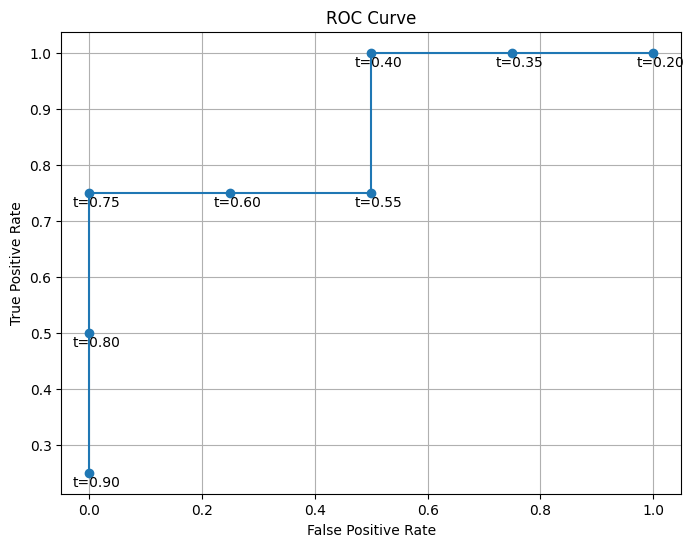

In [8]:
import matplotlib.pyplot as plt

# Extract FPR and TPR for plotting
FPRs = [pt[0] for pt in points]
TPRs = [pt[1] for pt in points]


plt.figure(figsize=(8, 6))
plt.plot(FPRs, TPRs, marker='o')

# Add threshold t as text for each point
for i, (fpr, tpr, t) in enumerate(points):
    plt.annotate(f't={t:.2f}', (fpr, tpr), textcoords="offset points", xytext=(5,-10), ha='center')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

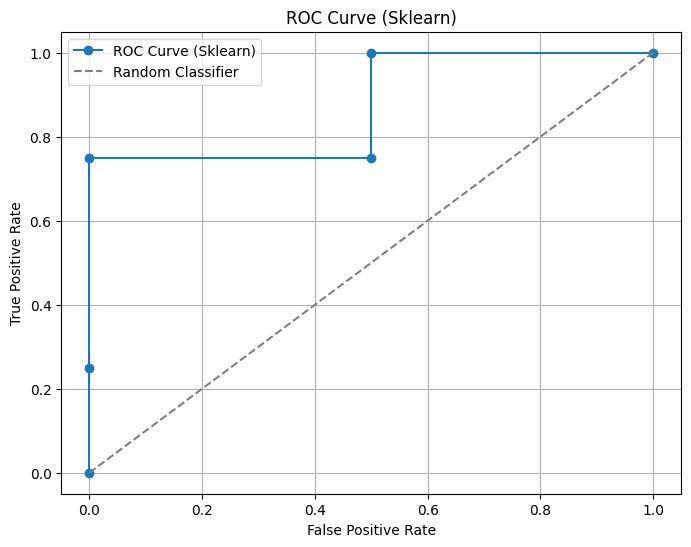

In [10]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
sk_fpr, sk_tpr, sk_thresholds = roc_curve(y_true, scores)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(sk_fpr, sk_tpr, marker='o', label='ROC Curve (Sklearn)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

# Add threshold t as text for each point (optional, as sklearn generates many thresholds)
# For better visualization, we might not want to plot all thresholds directly on the curve
# but rather show a few representative ones, or just plot the curve without them.
# For now, let's plot some thresholds, for example, every 5th one.
# for i, (fpr_val, tpr_val, thresh) in enumerate(zip(sk_fpr, sk_tpr, sk_thresholds)):
#    if i % 5 == 0: # Plot every 5th threshold for readability
#        plt.annotate(f't={thresh:.2f}', (fpr_val, tpr_val), textcoords="offset points", xytext=(5,-10), ha='center')

plt.title('ROC Curve (Sklearn)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()
plt.show()

In [11]:
# Calculate the Area Under the Curve (AUC)
roc_auc = auc(sk_fpr, sk_tpr)
print(f"AUC (Sklearn): {roc_auc:.2f}")

AUC (Sklearn): 0.88


In [12]:
from sklearn.linear_model import LogisticRegression

# Prepare the data for Logistic Regression
# Reshape 'scores' to be a 2D array as sklearn expects features in a 2D array
X = scores.reshape(-1, 1)
y = y_true

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X, y)

print("Logistic Regression Model trained successfully.")
print(f"Coefficients: {log_reg_model.coef_}")
print(f"Intercept: {log_reg_model.intercept_}")

Logistic Regression Model trained successfully.
Coefficients: [[0.52156395]]
Intercept: [-0.29688077]


In [13]:
log_reg_model.predict(X)

array([0, 1, 1, 1, 0, 1, 0, 0])

In [14]:
log_reg_model.predict_proba(X)

array([[0.52855225, 0.47144775],
       [0.46994369, 0.53005631],
       [0.49598569, 0.50401431],
       [0.45697497, 0.54302503],
       [0.54799378, 0.45200622],
       [0.4764444 , 0.5235556 ],
       [0.50250513, 0.49749487],
       [0.52204949, 0.47795051]])